# Megaline Model to Recommend A New Cell Plan 

In this project, I develop a machine-learning model to analyze the beahavior of current subscribers who are using legacy plans and recommend one of the newer plans: Smart or Ultra. 

I use behavior data about subscribers who have already switched to the new plans to train a classification model that will pick the right plan. 

Using Python, I first import and examine the dataset.

Next, I split the dataset into a training set, a validation set, and a test set. Then, I investigate the quality of different models by changing hyperparameters. Finlly, I check the quality of the model using the test set (setting the accuracy threshold at 75%) and sanity check the model to ensure it performs better than random chance.

## Open and look through data

First, we load and take a look at the dataset.

In [1]:
# Loading pandas
import pandas as pd

# Load data file
users = pd.read_csv('/datasets/users_behavior.csv')

# Print the general/summary information about the DataFrame
users.info()
print()

# Print a sample of the data
print(users.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB

   calls  minutes  messages   mb_used  is_ultra
0   40.0   311.90      83.0  19915.42         0
1   85.0   516.75      56.0  22696.96         0
2   77.0   467.66      86.0  21060.45         0
3  106.0   745.53      81.0   8437.39         1
4   66.0   418.74       1.0  14502.75         0


Here, we can see that 'is_ultra' is the target value (categorical, with 1 signifying that the user chose the Ultra plan and 0 signifying that they chose the Smart plan). The other columns are features showing monthly behavior (number of calls made, number of call minutes, number of texts, and internet traffic used in MB). Let's check how balanced the data in the target column is.

In [2]:
print('Ultra members:', users['is_ultra'].sum())

Ultra members: 985


Our source data is about 30% Ultra users and 70% Smart users, indicating a class imbalance. We'll need to keep this in mind when splitting our source data.

## Split source data

Now, we'll split the source data into a training set, a validation set, and a test set. Since we only have the source data (vs a separate test set) we'll need to split the source data following a 3:1:1 ratio (60% training, 20% validation, 20% test). These set sizes keep the triaining set as the largest portion, and the validation and test sets equal. 

We'll use train_test_split, but because this can only split the source data in two, we'll do the 3-way split in two steps. We'll need to use the stratify parameter to ensure each subset keeps the same class balance in the target column.

In [3]:
# import train_test_split function
from sklearn.model_selection import train_test_split

# First, split off test set specifying .2 as the test size
train_users, test_users = train_test_split(users, test_size=0.2, random_state=42, stratify=users['is_ultra'])

# Then, split off the validation set. Use .25 to set the validation set at 20% of original source (0.25 x 0.8 = 0.2)
train_users, val_users = train_test_split(train_users, test_size=0.25, random_state=42, stratify=train_users['is_ultra']) 

Now we'll define features and target variables for each set.

In [4]:
# Define variables for training set
features_train = train_users.drop('is_ultra', axis=1)
target_train = train_users['is_ultra']

# Define variables for validation set
features_val = val_users.drop('is_ultra', axis=1)
target_val = val_users['is_ultra']

# Define variables for test set
features_test = test_users.drop('is_ultra', axis=1)
target_test = test_users['is_ultra']

# Print the size of the tables stored in the six variables
print(features_train.shape)
print(target_train.shape)
print(features_val.shape)
print(target_val.shape)
print(features_test.shape)
print(target_test.shape)

(1928, 4)
(1928,)
(643, 4)
(643,)
(643, 4)
(643,)


We can see the sizes of the variables match a 3:1:1 ratio. Now we can start digging into different models!

## Investigate different models

In this step, we'll use the training set to train three different model types: a decision tree, a random forest, and a logistic regression. Then, we'll check the accuracy of these models using the validation set.

We'll start with training a decision tree model. To explore different max_depth values, we'll create a function to test different depths and identify the best model based on accuracy.

In [5]:
# Import DecisionTreeClassifier and accuracy_score from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define function to iterate over different depth options in the training algorithm
best_model = None
best_result = 0
for depth in range(1, 11):
    # Create a model with the given depth
    model = DecisionTreeClassifier(random_state=12345, max_depth= depth) 
    # Train the model
    model.fit(features_train, target_train) 
    # Get the model's predictions
    predictions_train = model.predict(features_train)
    # Calculate the accuracy
    result = accuracy_score(target_train, predictions_train) 
    if result > best_result:
        best_depth = depth
        best_result = result

# Print result
print("Accuracy of the best decision tree model on the training set (max_depth = {}): {}".format(best_depth, best_result))
# Define best model
best_tree_model = DecisionTreeClassifier(random_state=12345, max_depth= best_depth)
# Train best model on training set
best_tree_model.fit(features_train, target_train)
# Evaluate best model on validation set
val_accuracy = best_tree_model.score(features_val, target_val)
print("Accuracy of the best decision tree model on the validation set:", val_accuracy)


Accuracy of the best decision tree model on the training set (max_depth = 10): 0.8848547717842323
Accuracy of the best decision tree model on the validation set: 0.7620528771384136


These results show us that training performance is higher than validation performance, indicating moderate overfitting. The validation score does pass our 75% accuracy threshold at 76.2%, but we'll explore a random forest model to see if it can do even better. We'll explore different combinations of values for hyperparameters n_estimators and max_depth using GridSearchCV.

In [6]:
# Import RandomForestClassifier and GridSearchCV from sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid for both n_estimators and max_depth
param_grid = {
    'n_estimators': range(1, 21),       # Number of trees
    'max_depth': range(1,11)    # Same max_depth range as decision tree
}

# Set up the model
rf_model = RandomForestClassifier(random_state=54321)

# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='accuracy',        # Use accuracy as the scoring metric
    n_jobs=-1                  # Use all processors
)

# Fit the grid search on the training data
grid_search.fit(features_train, target_train)

# Print the best combination of parameters and the corresponding accuracy
print("Best random forest model parameters:", grid_search.best_params_)
print("Accuracy of the best random forest model on the training set:", grid_search.best_score_)

# Evaluate best model on the validation set
best_model = grid_search.best_estimator_
val_accuracy = best_model.score(features_val, target_val)
print("Accuracy of the best random forest model on the validation set:", val_accuracy)



Best random forest model parameters: {'max_depth': 9, 'n_estimators': 15}
Accuracy of the best random forest model on the training set: 0.8101675526545993
Accuracy of the best random forest model on the validation set: 0.7822706065318819


The most accurate forest model has 15 trees and a max_depth of 9. The training set still performs better than the validation set but the gap is much smaller, indicating very slight overfitting. However, the validation set shows a higher accuracy score at 78.2%. 

Finally, we'll look at a logistic regression model.

In [7]:
# Import LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression

# Initialize logistic regression constructor with parameters random_state=54321 and solver='liblinear'
model = LogisticRegression(random_state=5432, solver='liblinear') 
# Train model on training set
model.fit(features_train, target_train)
# Calculate accuracy score on training set
score_train = model.score(features_train, target_train)
# Calculate accuracy score on validation set
score_val = model.score(features_val, target_val)  

# Print results
print("Accuracy of the best logistic regression model on the training set:", score_train)
print("Accuracy of the best logistic regression model on the validation set:", score_val)


Accuracy of the best logistic regression model on the training set: 0.7064315352697096
Accuracy of the best logistic regression model on the validation set: 0.7060653188180405


The logistic regression model is the least accurate of the three. 

Based on this study, the best model appears to be the random forest model. We'll combine the validation set back into the training set and train our final model on this larger set.

In [8]:
# Define best model 
best_model = RandomForestClassifier(random_state=123, max_depth = 9, n_estimators = 15)

# Combine validation set back into training set
train_users = pd.concat([train_users, val_users], ignore_index=True)

# Train on training set
best_model.fit(features_train, target_train)

RandomForestClassifier(max_depth=9, n_estimators=15, random_state=123)

## Check quality of model

In this step, we'll use the test set to check the quality of the best model we selected. 

In [9]:
# Define predictions for training set
train_predictions = best_model.predict(features_train)
# Calculate accuracy for training set
train_accuracy= accuracy_score(target_train, train_predictions) 
# Calculate accuracy for test set
test_predictions = best_model.predict(features_test)
test_accuracy = accuracy_score(target_test, test_predictions)
# Print results
print('Accuracy')
print('Training set:', train_accuracy) 
print('Test set:', test_accuracy)

Accuracy
Training set: 0.8838174273858921
Test set: 0.8164852255054432


The accuracy drops slightly for the test set, but not by much, indicating that the model is generalizing fairly well. The 81.6% accuracy score surpasses our 75% threshold.

Finally, we'll sanity check our model.

## Sanity check

In this step, we'll see whether our model performs better than random chance. We'll weight the probabilities because we know there are far more Smart users than Ultra users.

In [10]:
import numpy as np

class_labels = [0, 1]

# Define the class probabilities (70% for 0, 30% for 1)
class_probs = [0.7, 0.3]

# Generate random predictions using the defined probabilities
random_preds = np.random.choice(class_labels, size=len(target_test), p=class_probs)

# Print accuracy of random guess model
print("Random guess accuracy:", accuracy_score(target_test, random_preds))

Random guess accuracy: 0.5583203732503889


Looks like our model does perform a lot better than random guessing. We can also take a look at the confusion matrix and classification report.

[[425  21]
 [ 97 100]]


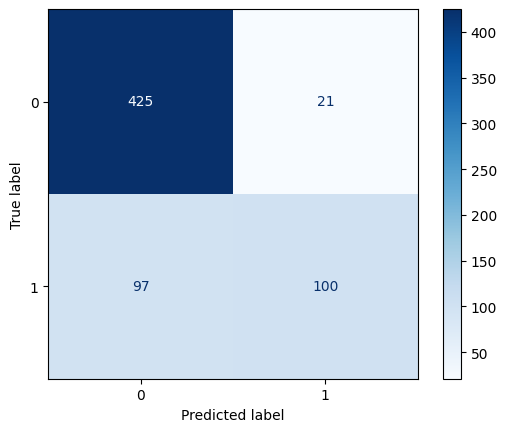

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
test_predictions = best_model.predict(features_test)

# Create confusion matrix
cm = confusion_matrix(target_test, test_predictions)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  
print(cm)

The model looks decent at predicting Smart users, but misses more Ultra users. However, when it predicts an Ultra user, it's typically correct. 

## Conclusion

In this project, I developed a classification model to help Megaline recommend the most appropriate cell plan—Smart or Ultra—based on user behavior. By analyzing usage patterns (calls, texts, internet traffic), the model can guide subscribers still using legacy plans toward the new option that best fits their needs.

I explored three types of models: a decision tree, a logistic regression model, and a random forest. After tuning hyperparameters and evaluating performance on a validation set, the random forest classifier emerged as the top performer. It achieved an accuracy of 81.6% on the test set, surpassing the defined 75% success threshold.

To ensure the model wasn’t just performing well due to chance, I ran a sanity check using weighted random predictions based on the target distribution (70% Smart, 30% Ultra). The model significantly outperformed this random baseline.

The confusion matrix further revealed that while the model is better at correctly identifying Smart users, it also predicts Ultra users with high precision, even though it misses some. This suggests that when the model does predict a user should be on the Ultra plan, the recommendation is likely to be reliable.

Overall, this model provides a valuable and data-driven tool to support personalized marketing or plan migration strategies. With additional data (e.g.,  more users or more months of usage data) and feature engineering, its performance could likely be improved even further.